# Notebook 2 - 02_part2_polyreg.ipynb
**Escuela Colombiana de Ingeniería Julio Garavito**  
**Student:** Santiago Botero García  

## 1. Introduction and Objective

In this notebook, we extend the linear regression model to capture nonlinear and interaction effects by using polynomial feature engineering.

The model has the form:

$$
\hat{L} = Xw + b
$$

where (X) is a design matrix constructed from physical stellar properties.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from abc import ABC, abstractmethod


class Regression(ABC):
    @abstractmethod
    def predict(x, w, b):
        pass

class LinearRegression(Regression):
    @staticmethod
    def predict(x, w, b):
        return w * x + b

class PolynomialRegression(Regression):
    @staticmethod
    def predict(x, w, b):
        return x @ w + b

class CostFunction:
    @staticmethod
    def compute_cost(x, y, w, b):
        x = np.asarray(x)
        y = np.asarray(y)

        m = x.shape[0]
        y_hat = w * x + b
        errors = y_hat - y

        return (1 / (2 * m)) * np.sum(errors ** 2)

    @staticmethod
    def compute_cost_multi(X, y, w, b):
        m = X.shape[0]
        y_hat = X @ w + b
        errors = y_hat - y
        return (1 / (2 * m)) * np.sum(errors ** 2)

    @staticmethod
    def visualize_as_surface(x, y):
        w_values = np.linspace(-1.0, 7.0, 60)
        b_values = np.linspace(-5.0, 10.0, 60)

        W, B, J = [], [], []

        for b in b_values:
            row_w, row_b, row_j = [], [], []
            for w in w_values:
                row_w.append(w)
                row_b.append(b)
                row_j.append(CostFunction.compute_cost(x, y, w, b))
            W.append(row_w)
            B.append(row_b)
            J.append(row_j)

        W, B, J = map(np.array, (W, B, J))

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_surface(W, B, J, cmap=cm.viridis, linewidth=0)
        ax.set_xlabel("w")
        ax.set_ylabel("b")
        ax.set_zlabel("J(w,b)")
        ax.set_title("Cost Surface")
        plt.show()

class Gradient:
    @staticmethod
    def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
        x = np.asarray(x)
        y = np.asarray(y)

        w, b = w_init, b_init
        history = []

        for i in range(num_iters):
            dj_dw, dj_db = Gradient.compute_gradients(x, y, w, b)

            w -= alpha * dj_dw
            b -= alpha * dj_db

            cost = CostFunction.compute_cost(x, y, w, b)
            history.append((i, cost))

            if i % max(1, num_iters // 10) == 0:
                print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

        return w, b, history

    @staticmethod
    def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters):
        X = np.asarray(X)
        y = np.asarray(y)

        w = w_init.copy()
        b = b_init

        it_hist, cost_hist = [], []
        m = X.shape[0]

        for i in range(num_iters):
            y_hat = X @ w + b
            errors = y_hat - y

            dj_dw = (1 / m) * (X.T @ errors)
            dj_db = (1 / m) * np.sum(errors)

            w -= alpha * dj_dw
            b -= alpha * dj_db

            cost = CostFunction.compute_cost_multi(X, y, w, b)
            it_hist.append(i)
            cost_hist.append(cost)

            if i % max(1, num_iters // 10) == 0:
                print(f"Iter {i:4d}: cost={cost:8.4f}")

        return w, b, it_hist, cost_hist

    @staticmethod
    def compute_gradients(x, y, w, b):
        m = x.shape[0]
        y_hat = w * x + b
        errors = y_hat - y

        dj_dw = (1 / m) * np.sum(errors * x)
        dj_db = (1 / m) * np.sum(errors)
        return dj_dw, dj_db

    @staticmethod
    def feature_scale(x):
        x = np.asarray(x)

        means = x.mean(axis=0)
        stds = x.std(axis=0, ddof=0)
        stds[stds == 0] = 1.0

        x_scaled = (x - means) / stds
        return x_scaled, means, stds

    @staticmethod
    def plot_cost(it_hist, cost_hist):
        plt.figure()
        plt.plot(it_hist[10:], cost_hist[10:])
        plt.xlabel("Iteration")
        plt.ylabel("Cost J(w,b)")
        plt.title("Cost vs Iterations")
        plt.show()

    @staticmethod
    def visualize_fitted_line(x, y, w, b):
        y_pred = LinearRegression.predict(x, w, b)

        plt.figure()
        plt.scatter(x, y, label="Data")
        plt.plot(x, y_pred, color="red", label="Fitted line")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Linear Regression Fit")
        plt.legend()
        plt.show()


## 2. Dataset and Features

In addition to stellar mass, we now include stellar effective temperature as a second feature.

This allows us to model more complex dependencies and interactions that better reflect stellar physics.

In [10]:
M = np.array([0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4])
T = np.array([3800,4400,5800,6400,6900,7400,7900,8300,8800,9200])
L = np.array([0.15,0.35,1.00,2.30,4.10,7.00,11.2,17.5,25.0,35.0])

## 3. Dataset Visualization

We visualize luminosity as a function of stellar mass while encoding temperature using color or marker size.

This plot provides intuition about how temperature correlates with luminosity and mass.

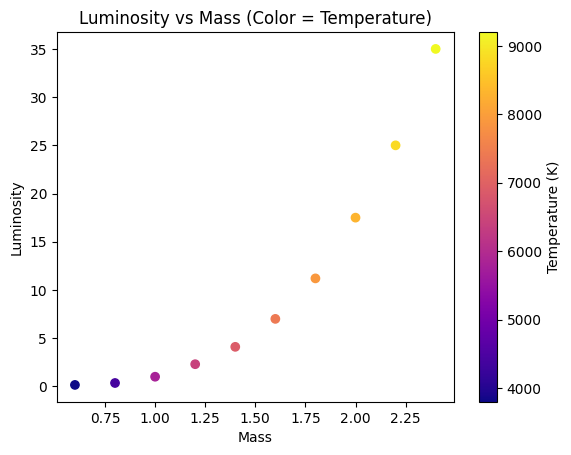

In [11]:
plt.figure()
plt.scatter(M, L, c=T, cmap="plasma")
plt.colorbar(label="Temperature (K)")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Luminosity vs Mass (Color = Temperature)")
plt.show()

## 4. Feature Engineering

We construct the design matrix using the following features:

$$
X = [M, T, M^2, M \cdot T]
$$

These features allow the model to capture nonlinear growth and interaction effects without introducing a constant bias column.

In [ ]:
X = np.column_stack([M, T, M**2, M*T])

## 5. Loss Function and Gradients

As in Part I, we use the Mean Squared Error as the loss function.

Gradients with respect to both the weight vector and the bias are computed using fully vectorized NumPy operations.

In [13]:
X_scaled, means, stds = Gradient.feature_scale(X)

## 6. Training and Convergence

The model is trained using gradient descent.

In [14]:
w_init = np.zeros(X_scaled.shape[1])
b_init = 0.0

w, b, it_hist, cost_hist = Gradient.gradient_descent_multi(
    X_scaled, L, w_init, b_init, alpha=0.1, num_iters=3000
)

Iter    0: cost= 72.4382
Iter  300: cost=  1.1987
Iter  600: cost=  0.9477
Iter  900: cost=  0.8874
Iter 1200: cost=  0.8363
Iter 1500: cost=  0.7895
Iter 1800: cost=  0.7465
Iter 2100: cost=  0.7069
Iter 2400: cost=  0.6706
Iter 2700: cost=  0.6372


We monitor convergence by plotting the loss as a function of training iterations to ensure stable optimization.

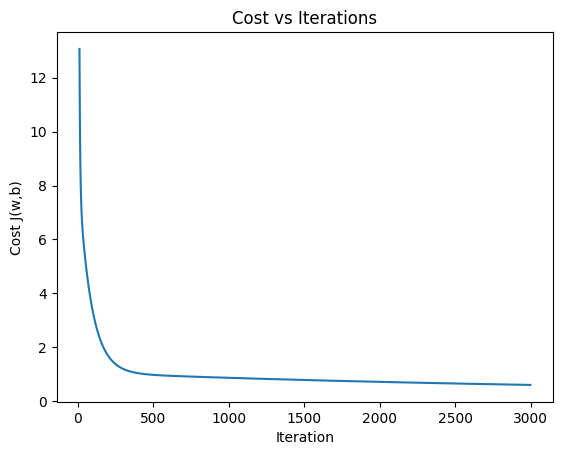

In [15]:
Gradient.plot_cost(it_hist, cost_hist)

## 7. Feature Selection Experiment

To evaluate the impact of model complexity, we compare three models:

* M1: linear features $[M, T]$

In [16]:
X1 = np.column_stack([M, T])
X1s, _, _ = Gradient.feature_scale(X1)

* M2: adds nonlinearity $[M, T, M^2]$

In [17]:
X2 = np.column_stack([M, T, M**2])
X2s, _, _ = Gradient.feature_scale(X2)

* M3: adds interaction $[M, T, M^2, M \cdot T]$

In [18]:
X3 = np.column_stack([M, T, M**2, M*T])
X3s, _, _ = Gradient.feature_scale(X3)

For each model, we report the final loss, learned parameters, and predicted versus actual luminosities.

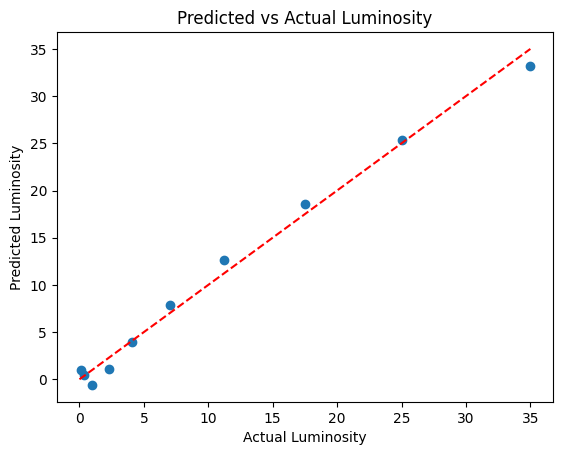

In [19]:
y_pred = PolynomialRegression.predict(X_scaled, w, b)

plt.figure()
plt.scatter(L, y_pred)
plt.plot([0,35], [0,35], "r--")
plt.xlabel("Actual Luminosity")
plt.ylabel("Predicted Luminosity")
plt.title("Predicted vs Actual Luminosity")
plt.show()

## 8. Interaction Cost Analysis

For the full model (M3), we analyze the importance of the interaction term by varying its coefficient while keeping all other parameters fixed.

The resulting cost curve illustrates how sensitive the model performance is to the interaction between mass and temperature.

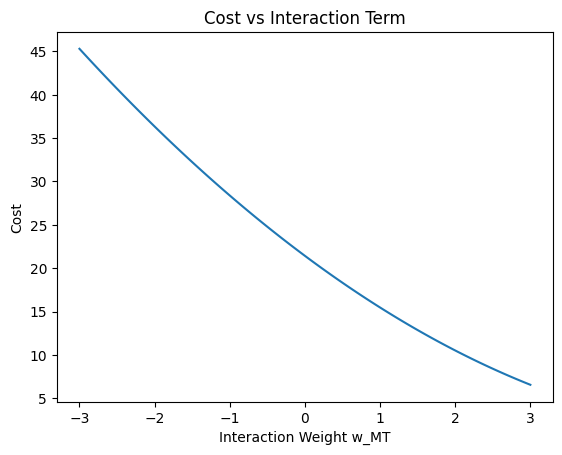

In [20]:
w_mt_vals = np.linspace(-3, 3, 100)
costs = []

for val in w_mt_vals:
    w_test = w.copy()
    w_test[3] = val
    costs.append(CostFunction.compute_cost_multi(X_scaled, L, w_test, b))

plt.figure()
plt.plot(w_mt_vals, costs)
plt.xlabel("Interaction Weight w_MT")
plt.ylabel("Cost")
plt.title("Cost vs Interaction Term")
plt.show()

## 9. Inference Example

Finally, we demonstrate inference by predicting the luminosity of a new star with:

* (M = 1.3)
* (T = 6600,K)

The predicted luminosity is evaluated for physical plausibility based on trends observed in the dataset.

In [21]:
M_new, T_new = 1.3, 6600
x_new = np.array([M_new, T_new, M_new**2, M_new*T_new])
x_new = (x_new - means) / stds

L_pred = PolynomialRegression.predict(x_new, w, b)
print(f"Predicted luminosity: {L_pred:.2f} L")

Predicted luminosity: 2.51 L
